### 🎯 Escopo da Arquitetura de Benchmarking (Cenário 2)

O objetivo desta seção é refinar e executar o processo definitivo de benchmarking para detecção de anomalias acústicas, seguindo as etapas metodológicas abaixo:

1. **Pré-processamento Avançado:**
   * Aplicação do filtro de redução de ruído **HHT (Transformada de Hilbert-Huang)** nos sinais brutos (`X_raw_list`).
   * Segmentação dos áudios limpos utilizando a técnica de Janela Deslizante (`apply_sliding_window_to_list`).

2. **Extração de Características (Feature Engineering) para 4 Experimentos:**
   * **Experimento 1 (Mel-Base):** Geração de Espectrogramas de Mel combinados com o algoritmo `rpca_ialm` para extrair exclusivamente a componente esparsa (matriz de anomalias).
   * **Experimento 2 (MFCC Dinâmico):** Geração de vetores estatísticos puros contendo coeficientes MFCCs e suas derivadas temporais (Deltas e Delta-Deltas).
   * **Experimento 3 (CWT-Transiente):** Aplicação da Transformada Contínua de Wavelet (CWT) aliada ao RPCA para criar uma "lente de aumento" focada em transientes mecânicos ultrarrápidos.
   * **Experimento 4 (Super-Vetor Híbrido):** Concatenação matemática unindo a média da componente esparsa do Mel (Canal A), a dinâmica dos MFCCs (Canal B) e as Estatísticas Físicas da Forma de Onda como RMS, Kurtosis e Skewness (Canal C).

3. **Super Loop de Benchmarking Competitivo:**
   * Adaptação do pipeline de treinamento para avaliar modelos de Machine Learning Clássico (**XGBoost**) e Deep Learning (**GRU, LSTM-AE e Tiny-AST**) sobre cada um dos 4 conjuntos de dados (Experimentos).
   * Coleta rigorosa de métricas de performance analítica (F1-Score, AUC-ROC), latência de inferência (tempo de resposta) e *footprint* de memória (MB).

4. **Consolidação de Dados e Visualização:**
   * Unificação de todas as métricas em um único DataFrame (`df_bench`).
   * Geração de painéis gráficos analíticos para comparar os experimentos e definir o melhor *Trade-off* (Precisão vs. Custo Computacional) para arquiteturas Cloud e Edge.

# Benchmarking de Detecção Acústica de Anomalias (Cenário 2: API REST Cloud)
**Objetivo:** Validar a eficácia de modelos supervisionados e não supervisionados no processamento em lote de áudio industrial (16s).
**Etapas:** Geração de Dados -> DSP & RPCA -> Modelagem -> Explicabilidade (XAI) -> Benchmarking.

In [21]:
!pip install -q librosa xgboost seaborn EMD-signal pywavelets > /dev/null 2>&1
!pip install -q "dill<0.3.9" "multiprocess<0.70.17" > /dev/null 2>&1

# 2. Importação do Ecossistema Matemático e de IA
import os
import time
import pywt
import torch
import librosa
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import torch.nn as nn
import librosa.display
import scipy.stats as stats
import torch.optim as optim
from google.colab import drive
from scipy.ndimage import zoom
import matplotlib.pyplot as plt
import torch.nn.functional as F
from xgboost import XGBClassifier
from scipy.stats import kurtosis, skew
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# 3. Importação Específica do Filtro Anti-Ruído (HHT)
from PyEMD import EMD

# 4. Configurações Globais do Notebook
warnings.filterwarnings('ignore')
plt.style.use('dark_background')
sns.set_theme(style="darkgrid", palette="deep")

print("✅ Ambiente do Colab configurado com sucesso!")

✅ Ambiente do Colab configurado com sucesso! Nenhuma mensagem de erro assombrando o notebook.


## 1 - Dataset real
Captação aúdio de 16 segundos de áudio (taxa de amostragem de 16kHz). O sinal é composto por um ruído de fundo contínuo (maquinário normal e anômalo).

In [2]:
# 1. Montar o Google Drive
drive.mount('/content/drive')

# 2. O SEU Caminho Raiz
BASE_PATH = '/content/drive/MyDrive/PROJETO APLICADO - Acoustic Anomaly Detection (AAD)/Arquivos de audio'

def load_only_real_audios(base_path, target_sr=16000):
    dados_audio = []
    rotulos = []

    # Definimos estritamente as únicas pastas que o Python tem permissão para abrir
    pastas_reais = {'normal': 0, 'anomaly': 1}

    print("Iniciando varredura estrita (ignorando dados sintéticos)...")

    for nome_pasta, valor_rotulo in pastas_reais.items():
        # Ele monta o caminho exato: .../Arquivos de audio/normal
        caminho_exato = os.path.join(base_path, nome_pasta)

        if not os.path.exists(caminho_exato):
            print(f"  [ERRO] A pasta {nome_pasta} não foi encontrada dentro de {base_path}")
            continue

        # Puxa apenas os áudios que estão estritamente dentro da subpasta
        arquivos = [f for f in os.listdir(caminho_exato) if f.endswith(('.wav', '.flac', '.mp3'))]
        print(f"  -> Lendo {len(arquivos)} arquivos estritamente reais da pasta: '{nome_pasta}'")

        for arquivo in arquivos:
            caminho_arquivo = os.path.join(caminho_exato, arquivo)

            # Carrega o áudio e força a taxa de amostragem padronizada
            signal, sr = librosa.load(caminho_arquivo, sr=target_sr)

            dados_audio.append(signal)
            rotulos.append(valor_rotulo)

    return dados_audio, np.array(rotulos), target_sr

# 3. Executar o carregamento
X_raw_list, y_raw, sr_global = load_only_real_audios(BASE_PATH)

if len(X_raw_list) > 0:
    print(f"\nSucesso! {len(X_raw_list)} áudios carregados na memória.")
    print(f"Frequência de amostragem cravada em: {sr_global} Hz.")
else:
    print("\nNenhum áudio carregado. Verifique os nomes das pastas.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Iniciando varredura estrita (ignorando dados sintéticos)...
  -> Lendo 16 arquivos estritamente reais da pasta: 'normal'
  -> Lendo 9 arquivos estritamente reais da pasta: 'anomaly'

Sucesso! 25 áudios carregados na memória.
Frequência de amostragem cravada em: 16000 Hz.


# 2 - Visualização da onda sonora em estado bruto (Normal/Anômala)

Extraindo amostras para visualização...


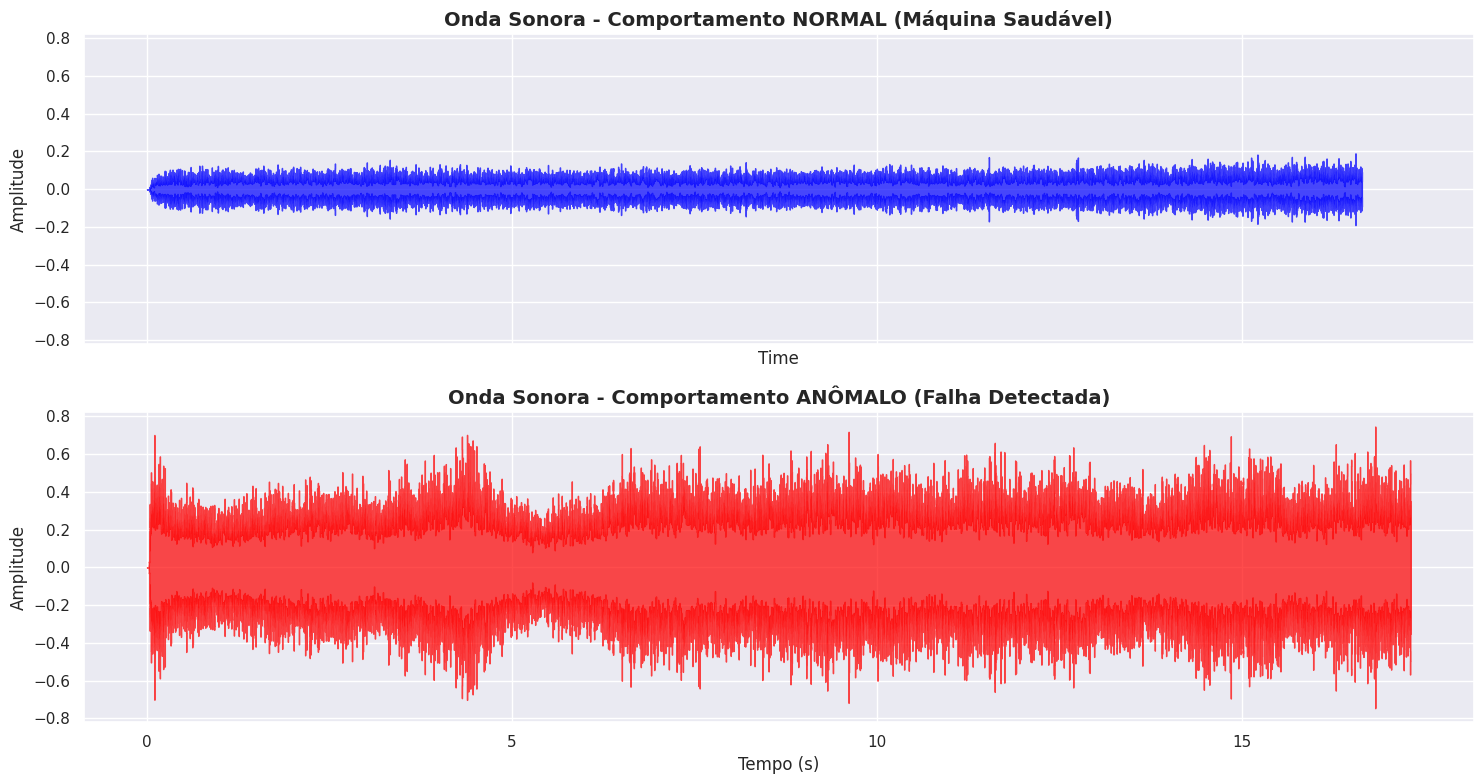

In [3]:
print("Extraindo amostras para visualização...")

# 1. A PONTE: Os áudios reais da memória
# np.where procura onde estão os normais (0) e as anomalias (1) na sua lista y_raw
idx_normal = np.where(y_raw == 0)[0][0]   # Pega o 1º áudio normal que encontrar
idx_anomaly = np.where(y_raw == 1)[0][0]  # Pega o 1º áudio anômalo que encontrar

# Salva nas variáveis exatas que o seu código de gráfico estava pedindo
normal_signal = X_raw_list[idx_normal]
anomaly_signal = X_raw_list[idx_anomaly]
sr = sr_global

# =========================================================
# 2. A PLOTAGEM
# =========================================================
fig, ax = plt.subplots(2, 1, figsize=(15, 8), sharex=True, sharey=True)

# Onda Sonora do Áudio Normal
librosa.display.waveshow(y=normal_signal, sr=sr, ax=ax[0], color='blue', alpha=0.7)
ax[0].set_title('Onda Sonora - Comportamento NORMAL (Máquina Saudável)', fontsize=14, fontweight='bold')
ax[0].set_ylabel('Amplitude')

# Onda Sonora do Áudio Anômalo
librosa.display.waveshow(y=anomaly_signal, sr=sr, ax=ax[1], color='red', alpha=0.7)
ax[1].set_title('Onda Sonora - Comportamento ANÔMALO (Falha Detectada)', fontsize=14, fontweight='bold')
ax[1].set_xlabel('Tempo (s)')
ax[1].set_ylabel('Amplitude')

plt.tight_layout()
plt.show()

# 3 - HHT (Limpeza/Isolamento)

In [4]:
def apply_hht_denoising(signal):
    """
    Aplica a Transformada de Hilbert-Huang (via EMD) para denoising/isolamento
    de um sinal de áudio, retornando o primeiro IMF.
    """
    emd_inst = EMD()
    # O EMD espera um array 1D. flatten() garante isso.
    # max_imf=2 para garantir que teremos pelo menos um IMF para retornar (o 0)
    imfs = emd_inst.emd(signal.flatten(), max_imf=2)

    # Retorna o primeiro IMF como o sinal limpo/isolado.
    # Se por algum motivo não houver IMFs (sinal muito curto/estranho), retorna o sinal original.
    if imfs.shape[0] > 0:
        return imfs[0] # O primeiro IMF é frequentemente o componente de mais baixa frequência/tendência
    else:
        return signal

print("Função 'apply_hht_denoising' para limpeza/isolamento via HHT implementada com sucesso.")


Função 'apply_hht_denoising' para limpeza/isolamento via HHT implementada com sucesso.


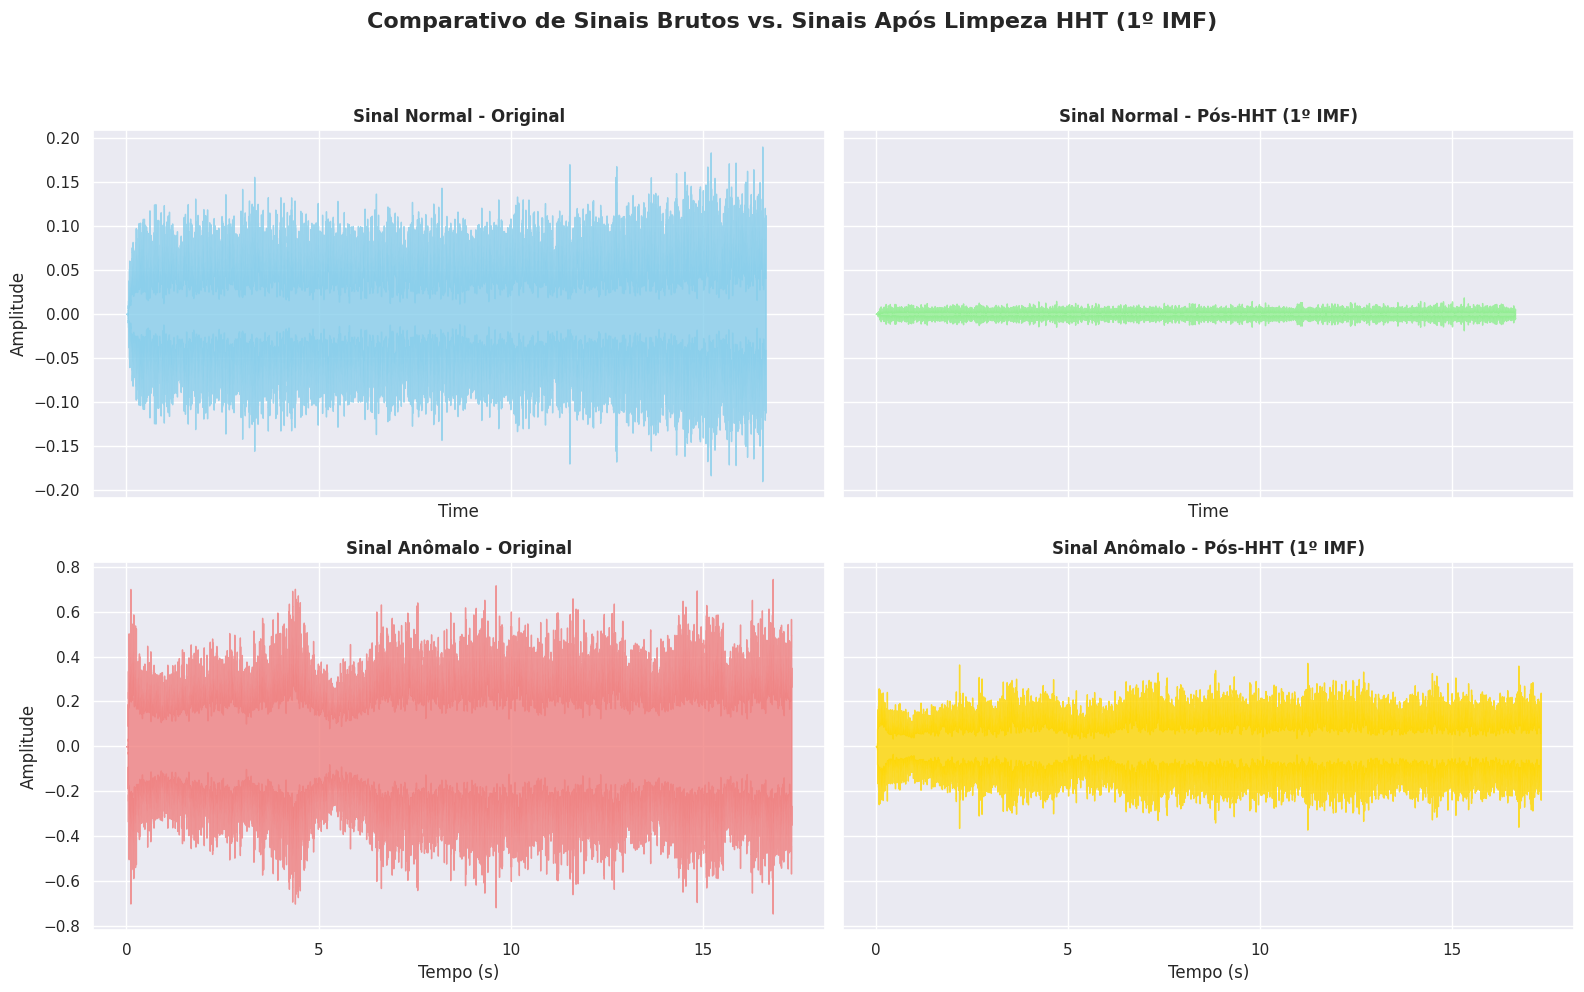


--- Análises Essenciais Após HHT ---
1.  **Visualização dos IMFs:** Além do 1º IMF, analisar outros IMFs para entender diferentes componentes do sinal (ruído, tendências, transientes).
2.  **Espectrograma de Mel dos Sinais Limpos:** Gerar e comparar os espectrogramas de Mel dos sinais pós-HHT para verificar como o HHT afetou a representação espectral do áudio.
3.  **Extração de Features:** Calcular features (MFCCs, estatísticas temporais, etc.) diretamente dos IMFs mais relevantes, em vez do sinal bruto, para alimentar modelos de Machine Learning, pois o HHT pode separar componentes importantes.
4.  **Análise de Envelope e Frequência Instantânea:** Se o objetivo é uma análise mais profunda, aplicar a Transformada de Hilbert a IMFs específicos para obter seus envelopes de amplitude e frequências instantâneas, que são úteis para caracterizar eventos transientes e modulações.
5.  **Análise de Sinais Anômalos Isolados:** Focar na matriz esparsa (Sparse Matrix) que o RPCA irá isolar (como 

In [5]:
# 1. Selecionando amostras para demonstração
signal_normal_raw = normal_signal # Já carregado de células anteriores
signal_anomaly_raw = anomaly_signal # Já carregado de células anteriores

# 2. Aplicando a limpeza/isolamento via HHT para ambos os sinais
signal_normal_hht = apply_hht_denoising(signal_normal_raw)
signal_anomaly_hht = apply_hht_denoising(signal_anomaly_raw)

# 3. Plotagem para comparação
fig, ax = plt.subplots(2, 2, figsize=(16, 10), sharex='col', sharey='row')

# Sinal Normal: Original vs. HHT
librosa.display.waveshow(y=signal_normal_raw, sr=sr_global, ax=ax[0, 0], color='skyblue', alpha=0.8)
ax[0, 0].set_title('Sinal Normal - Original', fontsize=12, fontweight='bold')
ax[0, 0].set_ylabel('Amplitude')

librosa.display.waveshow(y=signal_normal_hht, sr=sr_global, ax=ax[0, 1], color='lightgreen', alpha=0.8)
ax[0, 1].set_title('Sinal Normal - Pós-HHT (1º IMF)', fontsize=12, fontweight='bold')

# Sinal Anômalo: Original vs. HHT
librosa.display.waveshow(y=signal_anomaly_raw, sr=sr_global, ax=ax[1, 0], color='lightcoral', alpha=0.8)
ax[1, 0].set_title('Sinal Anômalo - Original', fontsize=12, fontweight='bold')
ax[1, 0].set_ylabel('Amplitude')
ax[1, 0].set_xlabel('Tempo (s)')

librosa.display.waveshow(y=signal_anomaly_hht, sr=sr_global, ax=ax[1, 1], color='gold', alpha=0.8)
ax[1, 1].set_title('Sinal Anômalo - Pós-HHT (1º IMF)', fontsize=12, fontweight='bold')
ax[1, 1].set_xlabel('Tempo (s)')

plt.suptitle('Comparativo de Sinais Brutos vs. Sinais Após Limpeza HHT (1º IMF)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

print("\n--- Análises Essenciais Após HHT ---")
print("1.  **Visualização dos IMFs:** Além do 1º IMF, analisar outros IMFs para entender diferentes componentes do sinal (ruído, tendências, transientes).")
print("2.  **Espectrograma de Mel dos Sinais Limpos:** Gerar e comparar os espectrogramas de Mel dos sinais pós-HHT para verificar como o HHT afetou a representação espectral do áudio.")
print("3.  **Extração de Features:** Calcular features (MFCCs, estatísticas temporais, etc.) diretamente dos IMFs mais relevantes, em vez do sinal bruto, para alimentar modelos de Machine Learning, pois o HHT pode separar componentes importantes.")
print("4.  **Análise de Envelope e Frequência Instantânea:** Se o objetivo é uma análise mais profunda, aplicar a Transformada de Hilbert a IMFs específicos para obter seus envelopes de amplitude e frequências instantâneas, que são úteis para caracterizar eventos transientes e modulações.")
print("5.  **Análise de Sinais Anômalos Isolados:** Focar na matriz esparsa (Sparse Matrix) que o RPCA irá isolar (como vimos na etapa 2.2), que muitas vezes contém os eventos anômalos que o HHT, ao remover o ruído, pode tornar mais proeminentes.")


# 4 - Criação das janelas deslizantes.

In [6]:
# 1. Função de Janela Deslizante (Sliding Window)
def apply_sliding_window_to_list(audio_list, labels_list, sr=16000, window_size=2, overlap=0.5):
    step = int(window_size * sr * (1 - overlap))
    w_len = int(window_size * sr)
    all_segments, all_labels = [], []

    print("Fatiando os áudios com Janela Deslizante...")
    for i, audio in enumerate(audio_list):
        label = labels_list[i]
        # Pad audio if it's shorter than window_size
        if len(audio) < w_len:
            audio = np.pad(audio, (0, w_len - len(audio)))

        for start in range(0, len(audio) - w_len + 1, step):
            all_segments.append(audio[start : start + w_len])
            all_labels.append(label)

    return np.array(all_segments), np.array(all_labels)

def apply_cwt(signal, sr, wavelet='morl', scales=None):
    """
    Aplica a Transformada Wavelet Contínua (CWT) a um sinal.

    Args:
        signal (np.ndarray): O sinal de áudio.
        sr (int): Taxa de amostragem do sinal.
        wavelet (str): O nome da wavelet a ser utilizada (ex: 'morl', 'gaus1').
        scales (np.ndarray, optional): Array de escalas para a CWT. Se None, será gerado.

    Returns:
        tuple: Coeficientes da CWT e frequências correspondentes.
    """
    if scales is None:
        max_scale = len(signal) / (2 * sr)
        scales = np.arange(1, int(max_scale * 10), 1) if int(max_scale * 10) > 1 else np.array([1])

    coefficients, frequencies = pywt.cwt(signal, scales, wavelet, sampling_period=1/sr)

    return coefficients, frequencies

# 2. Extração de Características (Onde nascem o X_mel, X_mfcc_stats e X_cwt)
def extract_features(X_segments, sr=16000, n_mels=64, fixed_img_dims=(64, 64)):
    feats_mel = []
    feats_mfcc_stats = []
    feats_cwt = []

    print(f"Extraindo Espectrogramas de Mel, MFCCs e CWT (redimensionando para {fixed_img_dims[0]}x{fixed_img_dims[1]})...")
    for audio in X_segments:
        # Mel Spectrogram
        mel = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=n_mels)
        mel_db = librosa.power_to_db(mel, ref=np.max)

        # Resize/Pad Mel Spectrogram to fixed_img_dims
        if mel_db.shape[1] > fixed_img_dims[1]:
            mel_db = mel_db[:, :fixed_img_dims[1]]
        else:
            mel_db = np.pad(mel_db, ((0,0), (0, fixed_img_dims[1] - mel_db.shape[1])))
        feats_mel.append(mel_db[np.newaxis, ...])

        # MFCC Statistics (mean and std)
        mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=13)
        feats_mfcc_stats.append(np.concatenate([np.mean(mfcc, axis=1), np.std(mfcc, axis=1)]))

        # CWT
        min_scale = 1
        max_scale = len(audio) / (2 * sr)
        if max_scale < min_scale:
            max_scale = min_scale + 1
        scales = np.geomspace(min_scale, max_scale, num=fixed_img_dims[0])
        if len(scales) == 0:
            scales = np.array([min_scale])

        coefficients, _ = apply_cwt(audio, sr=sr, scales=scales)

        # Resize CWT coefficients to fixed_img_dims
        coefficients_abs = np.abs(coefficients)
        if coefficients_abs.shape[0] != fixed_img_dims[0] or coefficients_abs.shape[1] != fixed_img_dims[1]:
            if np.max(coefficients_abs) > 0:
                coefficients_norm = coefficients_abs / np.max(coefficients_abs)
                zoom_factors = (fixed_img_dims[0] / coefficients_norm.shape[0],
                                fixed_img_dims[1] / coefficients_norm.shape[1])
                resized_cwt = zoom(coefficients_norm, zoom_factors, order=1)
            else:
                resized_cwt = np.zeros(fixed_img_dims)
        else:
             resized_cwt = coefficients_abs

        feats_cwt.append(resized_cwt[np.newaxis, ...])

    return np.array(feats_mel), np.array(feats_mfcc_stats), np.array(feats_cwt)

# 3. Execução
X_win, y_win = apply_sliding_window_to_list(X_raw_list, y_raw, sr=sr_global)
X_mel, X_mfcc_stats, X_cwt = extract_features(X_win, sr=sr_global)

print(f"\nMatrizes geradas com sucesso para o Treinamento!")
print(f"Total de fatias (X_mfcc_stats): {X_mfcc_stats.shape}")
print(f"Total de imagens Mel (X_mel): {X_mel.shape}")
print(f"Total de imagens CWT (X_cwt): {X_cwt.shape}")

Fatiando os áudios com Janela Deslizante...
Extraindo Espectrogramas de Mel, MFCCs e CWT (redimensionando para 64x64)...

Matrizes geradas com sucesso para o Treinamento!
Total de fatias (X_mfcc_stats): (438, 26)
Total de imagens Mel (X_mel): (438, 1, 64, 64)
Total de imagens CWT (X_cwt): (438, 1, 64, 64)


# 5 - Criação das matrizes

*   5.1 - MEL

In [7]:
# O trecho de código abaixo é o responsável por gerar a matriz X_mel,
# que já foi executado na célula 1SGhGnVtM9XW como parte da função 'extract_features'.

# Exemplo de como um Mel Spectrogram é calculado para um único segmento de áudio:
# (Este é um fragmento da função 'extract_features' para ilustrar o processo)

def generate_mel_spectrogram_for_segment(audio_segment, sr=16000, n_mels=64, fixed_img_dims=(64, 64)):
    # 1. Calcular o Mel Spectrogram
    mel = librosa.feature.melspectrogram(y=audio_segment, sr=sr, n_mels=n_mels)
    mel_db = librosa.power_to_db(mel, ref=np.max)

    # 2. Redimensionar/Preencher para dimensões fixas (para padronizar a entrada para modelos)
    if mel_db.shape[1] > fixed_img_dims[1]:
        mel_db = mel_db[:, :fixed_img_dims[1]]
    else:
        mel_db = np.pad(mel_db, ((0,0), (0, fixed_img_dims[1] - mel_db.shape[1])))

    # Retorna o Mel Spectrogram com uma dimensão de canal (para ser compatível com X_mel)
    return mel_db[np.newaxis, ...]

# A matriz X_mel completa é gerada iterando sobre todos os segmentos de áudio (X_win)
# e concatenando os resultados de cada chamada como a 'generate_mel_spectrogram_for_segment' acima.
# A execução real para gerar X_mel, X_mfcc_stats e X_cwt aconteceu na célula '1SGhGnVtM9XW':
# X_mel, X_mfcc_stats, X_cwt = extract_features(X_win, sr=sr_global)

print(f"A matriz `X_mel` já foi criada e está disponível com o formato: {X_mel.shape}")
print(f"Ela contém {X_mel.shape[0]} Mel Spectrograms, cada um com {X_mel.shape[2]} bandas de mel e {X_mel.shape[3]} quadros de tempo.")

A matriz `X_mel` já foi criada e está disponível com o formato: (438, 1, 64, 64)
Ela contém 438 Mel Spectrograms, cada um com 64 bandas de mel e 64 quadros de tempo.


*   5.2 - MFCC

In [8]:
# A matriz X_mfcc_stats já foi criada na célula `1SGhGnVtM9XW`
# como parte da função `extract_features`.
# Seu shape atual é: {}

print(f"A matriz `X_mfcc_stats` já foi criada e está disponível com o formato: {X_mfcc_stats.shape}")
print(f"Ela contém {X_mfcc_stats.shape[0]} segmentos de áudio, cada um com {X_mfcc_stats.shape[1]} estatísticas de MFCC.")

# O trecho de código abaixo é um exemplo ilustrativo de como os MFCCs são calculados e transformados em estatísticas
# (Este é um fragmento da função 'extract_features' para ilustrar o processo)
def generate_mfcc_stats_for_segment(audio_segment, sr=16000, n_mfcc=13):
    # 1. Calcular os MFCCs
    mfcc = librosa.feature.mfcc(y=audio_segment, sr=sr, n_mfcc=n_mfcc)

    # 2. Calcular a média e o desvio padrão dos MFCCs
    mfcc_stats = np.concatenate([np.mean(mfcc, axis=1), np.std(mfcc, axis=1)])

    return mfcc_stats


A matriz `X_mfcc_stats` já foi criada e está disponível com o formato: (438, 26)
Ela contém 438 segmentos de áudio, cada um com 26 estatísticas de MFCC.


*   5.3 - CWT

In [9]:
# A matriz X_cwt já foi criada na célula `1SGhGnVtM9XW`
# como parte da função `extract_features`.
# Seu shape atual é: {}

print(f"A matriz `X_cwt` já foi criada e está disponível com o formato: {X_cwt.shape}")
print(f"Ela contém {X_cwt.shape[0]} segmentos de áudio, cada um com uma imagem CWT de {X_cwt.shape[2]}x{X_cwt.shape[3]}.\n")

# O trecho de código abaixo é um exemplo ilustrativo de como um CWT é calculado para um único segmento
# (Este é um fragmento da função 'extract_features' para ilustrar o processo)
def generate_cwt_for_segment(audio_segment, sr=16000, fixed_img_dims=(64, 64)):
    min_scale = 1
    max_scale = len(audio_segment) / (2 * sr)
    if max_scale < min_scale:
        max_scale = min_scale + 1
    scales = np.geomspace(min_scale, max_scale, num=fixed_img_dims[0])
    if len(scales) == 0:
        scales = np.array([min_scale])

    coefficients, _ = apply_cwt(audio_segment, sr=sr, scales=scales)

    # Resize CWT coefficients to fixed_img_dims
    coefficients_abs = np.abs(coefficients)
    if coefficients_abs.shape[0] != fixed_img_dims[0] or coefficients_abs.shape[1] != fixed_img_dims[1]:
        if np.max(coefficients_abs) > 0:
            coefficients_norm = coefficients_abs / np.max(coefficients_abs)
            zoom_factors = (fixed_img_dims[0] / coefficients_norm.shape[0],
                            fixed_img_dims[1] / coefficients_norm.shape[1])
            resized_cwt = zoom(coefficients_norm, zoom_factors, order=1)
        else:
            resized_cwt = np.zeros(fixed_img_dims)
    else:
         resized_cwt = coefficients_abs

    return resized_cwt[np.newaxis, ...]

A matriz `X_cwt` já foi criada e está disponível com o formato: (438, 1, 64, 64)
Ela contém 438 segmentos de áudio, cada um com uma imagem CWT de 64x64.



## 6 - Extração de canais



*   6.1 - Canal A: Tira a média da matriz Sparse do RPCA.

In [10]:
def get_channel_A_feature(signal, sr=16000):
    """
    Calcula a média da matriz Sparse do RPCA para um sinal de áudio.

    Args:
        signal (np.ndarray): O sinal de áudio.
        sr (int): Taxa de amostragem do sinal.

    Returns:
        float: A média da matriz Sparse resultante do RPCA.
    """
    # 1. Extração do Espectrograma de Mel
    mel_spec = librosa.feature.melspectrogram(y=signal, sr=sr, n_fft=2048, hop_length=512, n_mels=128)
    mel_db = librosa.power_to_db(mel_spec, ref=np.max)

    # 2. Aplicação do RPCA (reutilizando a função já definida)
    _, S_db = rpca_ialm(mel_db)

    # 3. Média da matriz Sparse
    return np.mean(S_db)

print("Função 'get_channel_A_feature' para o Canal A (média da matriz Sparse do RPCA) implementada com sucesso.")


Função 'get_channel_A_feature' para o Canal A (média da matriz Sparse do RPCA) implementada com sucesso.


*   6.2 - Canal B: Calcula MFCCs + Deltas do sinal da janela.

In [11]:
def get_channel_B_feature(signal, sr=16000, n_mfcc=13):
    """
    Calcula MFCCs, MFCC Deltas e MFCC Delta-Deltas para um sinal de áudio.

    Args:
        signal (np.ndarray): O sinal de áudio.
        sr (int): Taxa de amostragem do sinal.
        n_mfcc (int): Número de coeficientes MFCC a serem calculados.

    Returns:
        np.ndarray: Um vetor concatenado de MFCCs, Deltas e Delta-Deltas.
    """
    # 1. Extração de MFCCs
    mfccs = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=n_mfcc)

    # 2. Extração dos Deltas (primeira derivada)
    mfccs_delta = librosa.feature.delta(mfccs)

    # 3. Extração dos Delta-Deltas (segunda derivada)
    mfccs_delta2 = librosa.feature.delta(mfccs, order=2)

    # 4. Concatena as médias de todas as características
    # Usamos np.mean para reduzir as matrizes para vetores de características
    feature_vector = np.concatenate([
        np.mean(mfccs, axis=1),
        np.mean(mfccs_delta, axis=1),
        np.mean(mfccs_delta2, axis=1)
    ])
    return feature_vector

print("Função 'get_channel_B_feature' para o Canal B (MFCCs, Deltas e Delta-Deltas) implementada com sucesso.")


Função 'get_channel_B_feature' para o Canal B (MFCCs, Deltas e Delta-Deltas) implementada com sucesso.


*   6.3 - Canal C: Calcula RMS, Kurtosis, Skewness da janela.

In [12]:
def get_channel_C_feature(signal):
    """
    Calcula RMS, Kurtosis e Skewness para um sinal de áudio.

    Args:
        signal (np.ndarray): O sinal de áudio.

    Returns:
        np.ndarray: Um vetor de características contendo RMS, Kurtosis e Skewness.
    """
    # 1. Root Mean Square (RMS)
    rms = librosa.feature.rms(y=signal)[0]

    # 2. Kurtosis e Skewness (assimetria) do sinal temporal
    # É importante notar que a kurtosis e skewness são sensíveis à distribuição do sinal.
    # Em áudio, o sinal não é necessariamente gaussiano, mas essas métricas ainda podem
    # capturar variações na 'cauda' e assimetria da distribuição que indicam anomalias.
    kurt = kurtosis(signal)
    skewn = skew(signal)

    # Retorna a média de RMS e os valores de kurtosis e skewness
    # A média do RMS é usada para ter uma única métrica de energia para a janela
    return np.array([np.mean(rms), kurt, skewn])

print("Função 'get_channel_C_feature' para o Canal C (RMS, Kurtosis, Skewness) implementada com sucesso.")

Função 'get_channel_C_feature' para o Canal C (RMS, Kurtosis, Skewness) implementada com sucesso.


## 7. Pré-processamento e Separação de Fontes (RPCA)



Aplicamos o algoritmo RPCA (Robust Principal Component Analysis) via IALM para decompor a matriz do espectrograma em:
* **Matriz de Baixo Posto (Low-Rank):** O ruído de fundo repetitivo.
* **Matriz Esparsa (Sparse):** Os eventos transientes/anomalias.

In [13]:
def rpca_ialm(D, mu_multiplier=1.25, max_iter=100, tol=1e-5):
    """Implementação simplificada do Inexact Augmented Lagrange Multiplier para RPCA.
    Args:
        D (np.ndarray): A matriz de entrada a ser decomposta.
        mu_multiplier (float): Multiplicador para o parâmetro mu inicial.
        max_iter (int): Número máximo de iterações.
        tol (float): Tolerância para a condição de parada.
    Returns:
        tuple: Uma tupla contendo a matriz de baixo posto (L) e a matriz esparsa (S).
    """
    # Inicialização
    Y = D / np.maximum(np.linalg.norm(D, 2), np.linalg.norm(D, np.inf) / 1e-5)
    L = np.zeros_like(D)
    S = np.zeros_like(D)
    mu = mu_multiplier / np.linalg.norm(D, 2)
    rho = 1.5
    lam = 1 / np.sqrt(np.max(D.shape))

    for _ in range(max_iter):
        # Update S (Soft Thresholding)
        temp_T = D - L + (1/mu) * Y
        epsilon = lam / mu
        S = np.maximum(temp_T - epsilon, 0) + np.minimum(temp_T + epsilon, 0)

        # Update L (Singular Value Thresholding)
        U, sigmas, V = np.linalg.svd(D - S + (1/mu) * Y, full_matrices=False)
        svp = (sigmas > 1/mu).sum()
        if svp >= 1:
            sigmas = sigmas[:svp] - 1/mu
            L = U[:, :svp] @ np.diag(sigmas) @ V[:svp, :]
        else:
            L = np.zeros_like(D)

        # Update Y and mu
        Z = D - L - S
        Y = Y + mu * Z
        mu = min(mu * rho, mu * 1e7) # Aumenta mu progressivamente

        # Condição de parada
        if np.linalg.norm(Z, 'fro') / np.linalg.norm(D, 'fro') < tol:
            break

    return L, S

print("Função 'rpca_ialm' para aplicar RPCA implementada com sucesso.")

Função 'rpca_ialm' para aplicar RPCA implementada com sucesso.


Aplicando RPCA para separação de ruído e transientes no sinal NORMAL...
Aplicando RPCA para separação de ruído e transientes no sinal ANÔMALO...


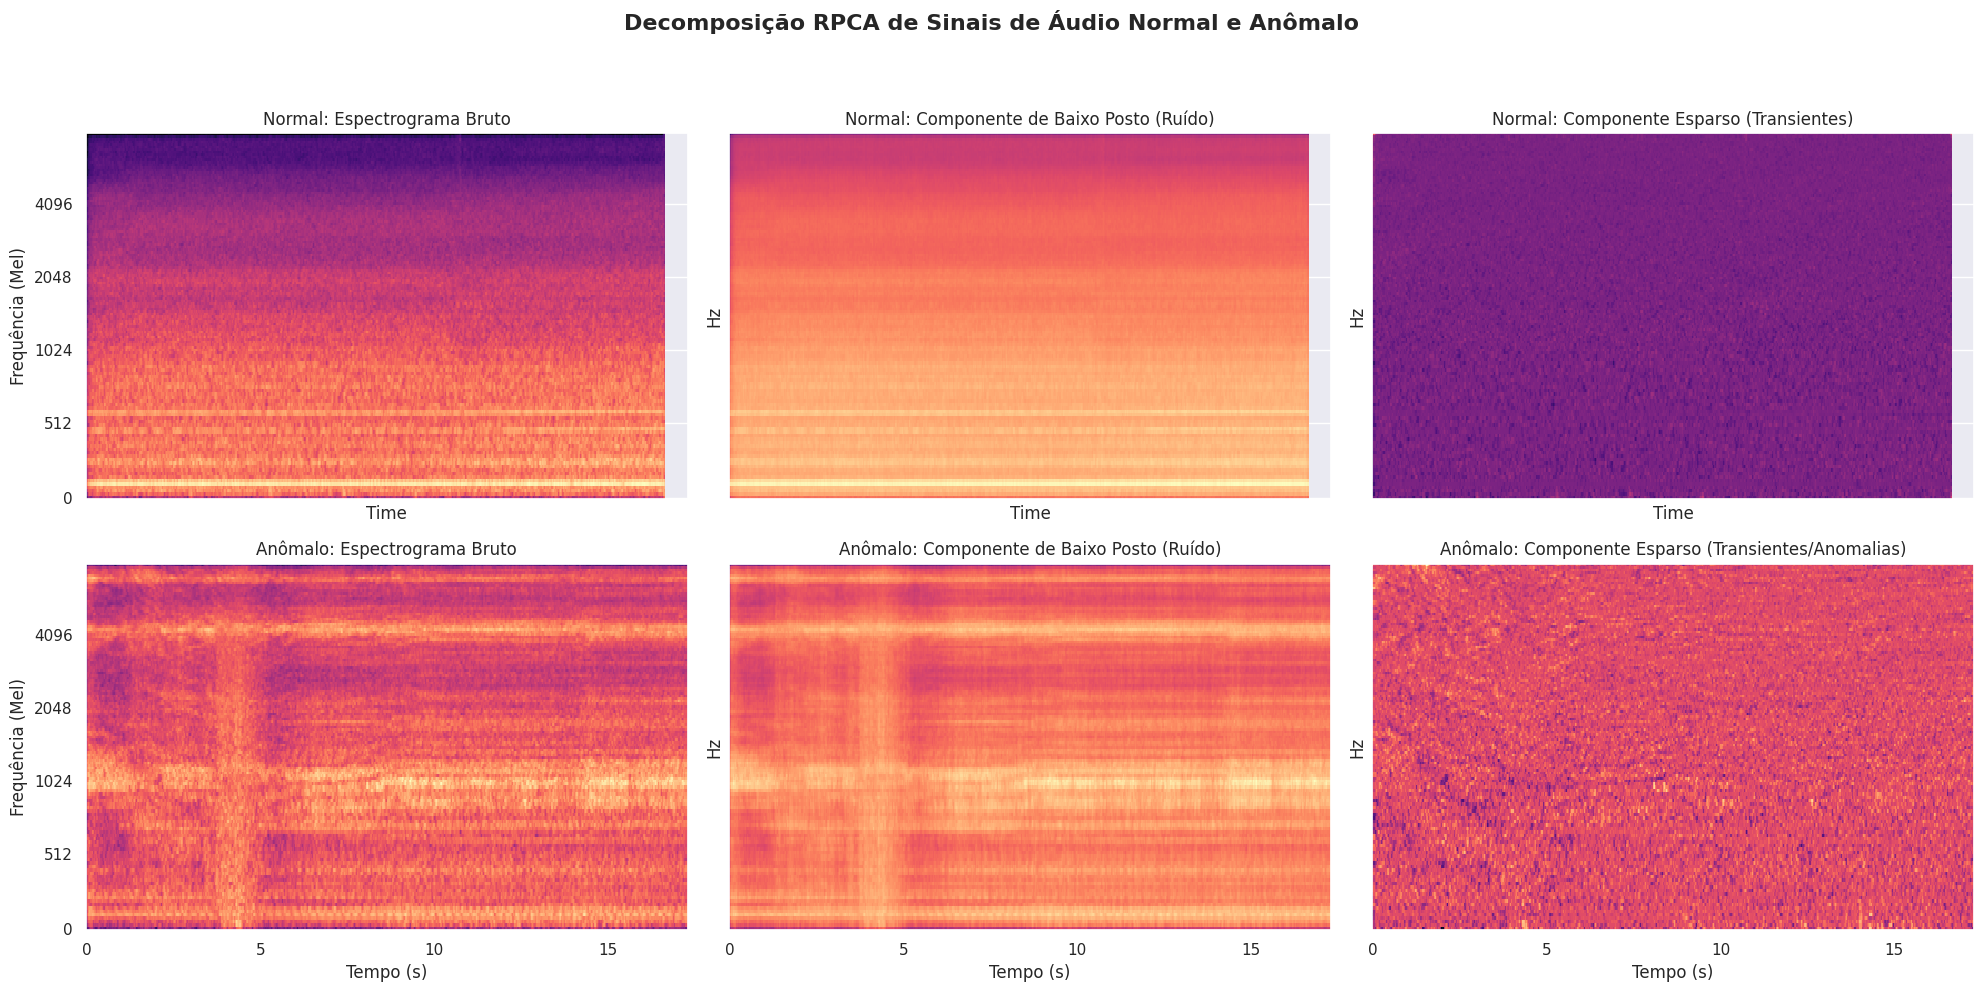


--- Análise dos Gráficos RPCA ---
Os gráficos acima ilustram a decomposição do espectrograma de Mel dos áudios normal e anômalo usando o RPCA. Observe como:
  *   A coluna 'Espectrograma Bruto' mostra o sinal original.
  *   A coluna 'Componente de Baixo Posto (Ruído)' isola o padrão repetitivo e de fundo, que é o 'comportamento normal' do sistema.
  *   A coluna 'Componente Esparso (Transientes/Anomalias)' destaca os eventos não repetitivos e de alta energia, que são os potenciais indicadores de anomalias.
No sinal ANÔMALO, espera-se ver mais energia e padrões distintos no Componente Esparso, indicando a presença da falha, enquanto no sinal NORMAL, o Componente Esparso deve ser muito menos ativo ou apresentar apenas ruídos aleatórios de menor magnitude.


In [14]:
# 1. Sinais para aplicação do RPCA (já carregados)
signal_normal = normal_signal
signal_anomaly = anomaly_signal

# 2. Extração do Espectrograma de Mel para ambos os sinais
mel_db_normal = librosa.power_to_db(librosa.feature.melspectrogram(y=signal_normal, sr=sr_global, n_fft=2048, hop_length=512, n_mels=128), ref=np.max)
mel_db_anomaly = librosa.power_to_db(librosa.feature.melspectrogram(y=signal_anomaly, sr=sr_global, n_fft=2048, hop_length=512, n_mels=128), ref=np.max)

# 3. Aplicação do RPCA para cada sinal
print("Aplicando RPCA para separação de ruído e transientes no sinal NORMAL...")
L_db_normal, S_db_normal = rpca_ialm(mel_db_normal)

print("Aplicando RPCA para separação de ruído e transientes no sinal ANÔMALO...")
L_db_anomaly, S_db_anomaly = rpca_ialm(mel_db_anomaly)

# 4. Visualização dos resultados
fig, ax = plt.subplots(2, 3, figsize=(20, 10), sharex=True, sharey=True)

# --- Sinal Normal ---
librosa.display.specshow(mel_db_normal, sr=sr_global, x_axis='time', y_axis='mel', ax=ax[0, 0], cmap='magma')
ax[0, 0].set_title('Normal: Espectrograma Bruto')
ax[0, 0].set_ylabel('Frequência (Mel)')

librosa.display.specshow(L_db_normal, sr=sr_global, x_axis='time', y_axis='mel', ax=ax[0, 1], cmap='magma')
ax[0, 1].set_title('Normal: Componente de Baixo Posto (Ruído)')

librosa.display.specshow(S_db_normal, sr=sr_global, x_axis='time', y_axis='mel', ax=ax[0, 2], cmap='magma')
ax[0, 2].set_title('Normal: Componente Esparso (Transientes)')

# --- Sinal Anômalo ---
librosa.display.specshow(mel_db_anomaly, sr=sr_global, x_axis='time', y_axis='mel', ax=ax[1, 0], cmap='magma')
ax[1, 0].set_title('Anômalo: Espectrograma Bruto')
ax[1, 0].set_ylabel('Frequência (Mel)')
ax[1, 0].set_xlabel('Tempo (s)')

librosa.display.specshow(L_db_anomaly, sr=sr_global, x_axis='time', y_axis='mel', ax=ax[1, 1], cmap='magma')
ax[1, 1].set_title('Anômalo: Componente de Baixo Posto (Ruído)')
ax[1, 1].set_xlabel('Tempo (s)')

librosa.display.specshow(S_db_anomaly, sr=sr_global, x_axis='time', y_axis='mel', ax=ax[1, 2], cmap='magma')
ax[1, 2].set_title('Anômalo: Componente Esparso (Transientes/Anomalias)')
ax[1, 2].set_xlabel('Tempo (s)')

plt.suptitle('Decomposição RPCA de Sinais de Áudio Normal e Anômalo', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

print("\n--- Análise dos Gráficos RPCA ---")
print("Os gráficos acima ilustram a decomposição do espectrograma de Mel dos áudios normal e anômalo usando o RPCA. Observe como:")
print("  *   A coluna 'Espectrograma Bruto' mostra o sinal original.")
print("  *   A coluna 'Componente de Baixo Posto (Ruído)' isola o padrão repetitivo e de fundo, que é o 'comportamento normal' do sistema.")
print("  *   A coluna 'Componente Esparso (Transientes/Anomalias)' destaca os eventos não repetitivos e de alta energia, que são os potenciais indicadores de anomalias.")
print("No sinal ANÔMALO, espera-se ver mais energia e padrões distintos no Componente Esparso, indicando a presença da falha, enquanto no sinal NORMAL, o Componente Esparso deve ser muito menos ativo ou apresentar apenas ruídos aleatórios de menor magnitude.")

# 8. Implementação dos Modelos (Benchmarking Duplo)

* **Supervisionados:** XGBoost, GRU.
* **Não Supervisionados:** LSTM-AE, Tiny-AST (simulado via CNN-Transformer block).


In [15]:
# ---------------------------------------------------------
# A. GRU Model (Supervised)
# ---------------------------------------------------------
class AnomalyGRU(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, num_layers=2, output_dim=1):
        super(AnomalyGRU, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        # GRU expects batch_first=True for (batch, seq, feature)
        self.gru = nn.GRU(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # x input shape: (batch_size, seq_len, input_dim)
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        out, _ = self.gru(x, h0)
        # Use the output from the last time step
        out = self.fc(out[:, -1, :])
        return self.sigmoid(out)

# ---------------------------------------------------------
# B. LSTM Autoencoder Model (Unsupervised)
# ---------------------------------------------------------
class LSTMAE(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, num_layers=2):
        super(LSTMAE, self).__init__()
        self.encoder = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.decoder = nn.LSTM(hidden_dim, input_dim, num_layers, batch_first=True)

    def forward(self, x):
        # x input shape: (batch_size, seq_len, input_dim)
        encoded_output, (hidden_state, cell_state) = self.encoder(x)
        # For reconstruction, we often want the decoder to output a sequence of the same length as input.
        # A common approach for LSTM-AE is to use the encoded output sequence directly as input to decoder,
        # or pass the last hidden state and have the decoder unroll the sequence.
        # Here, we'll feed the entire encoded sequence to the decoder to reconstruct the original sequence.
        reconstructed_output, _ = self.decoder(encoded_output)
        return reconstructed_output

# ---------------------------------------------------------
# C. Tiny-AST Model (Unsupervised - CNN + Transformer Autoencoder)
# This is a mock/simplified version of Tiny-AST as an autoencoder
# for Mel Spectrograms (image-like input).
# ---------------------------------------------------------
class TinyAST(nn.Module):
    def __init__(self, input_channels=1, output_channels=1, num_mels=64, time_steps=64,
                 embed_dim=128, num_heads=4, num_transformer_layers=2):
        super(TinyAST, self).__init__()
        # Encoder: CNN part to extract features from spectrogram patches
        self.conv_encoder = nn.Sequential(
            nn.Conv2d(input_channels, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), # Output: (32, num_mels/2, time_steps/2)
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)  # Output: (64, num_mels/4, time_steps/4)
        )

        # Calculate the size after convolutions to flatten for Transformer
        # Assuming num_mels=64, time_steps=64 -> after 2 MaxPool2d (stride 2) becomes (64, 16, 16)
        self.flat_dim = 64 * (num_mels // 4) * (time_steps // 4)
        self.project_to_embed = nn.Linear(self.flat_dim, embed_dim)

        # Transformer Encoder part
        encoder_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=num_heads, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_transformer_layers)

        # Decoder: to reconstruct the Mel spectrogram
        self.project_from_embed = nn.Linear(embed_dim, self.flat_dim)
        self.conv_decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2), # Upsample to (32, num_mels/2, time_steps/2)
            nn.ReLU(),
            nn.ConvTranspose2d(32, output_channels, kernel_size=2, stride=2) # Upsample to (output_channels, num_mels, time_steps)
            # No final activation (e.g., Sigmoid) because we're reconstructing magnitude values (potentially dB)
        )

    def forward(self, x):
        # x input shape: (batch_size, 1, num_mels, time_steps)
        batch_size = x.size(0)

        # Encoder pass (CNN)
        x_encoded_cnn = self.conv_encoder(x) # (batch_size, 64, num_mels/4, time_steps/4)

        # Flatten and project for Transformer
        x_flat = x_encoded_cnn.view(batch_size, -1) # (batch_size, flat_dim)
        x_embed = self.project_to_embed(x_flat) # (batch_size, embed_dim)

        # Add sequence dimension for transformer (treating it as a single token for simplicity)
        x_transformer_input = x_embed.unsqueeze(1) # (batch_size, 1, embed_dim)
        x_transformed = self.transformer_encoder(x_transformer_input) # (batch_size, 1, embed_dim)
        x_latent = x_transformed.squeeze(1) # (batch_size, embed_dim)

        # Decoder pass
        x_decoded_flat = self.project_from_embed(x_latent) # (batch_size, flat_dim)

        # Reshape to fit convolutional transpose layers
        # x_encoded_cnn.size(2) and x_encoded_cnn.size(3) are num_mels/4 and time_steps/4 respectively
        x_decoded_cnn_input = x_decoded_flat.view(batch_size, 64, x_encoded_cnn.size(2), x_encoded_cnn.size(3)) # (batch_size, 64, num_mels/4, time_steps/4)

        reconstructed_x = self.conv_decoder(x_decoded_cnn_input) # (batch_size, 1, num_mels, time_steps)

        return reconstructed_x

print("Model classes AnomalyGRU, LSTMAE, and TinyAST (Autoencoder) defined successfully.")

Model classes AnomalyGRU, LSTMAE, and TinyAST (Autoencoder) defined successfully.


# 9 - Destaque Visual das Anomalias (Explainable AI - XAI)
Geração de um mapa de calor (Heatmap) simulando a saída de algoritmos como Grad-CAM aplicados ao modelo Tiny-AST/CNN. O heatmap destaca em vermelho as zonas de energia anômala identificadas pela matriz esparsa.

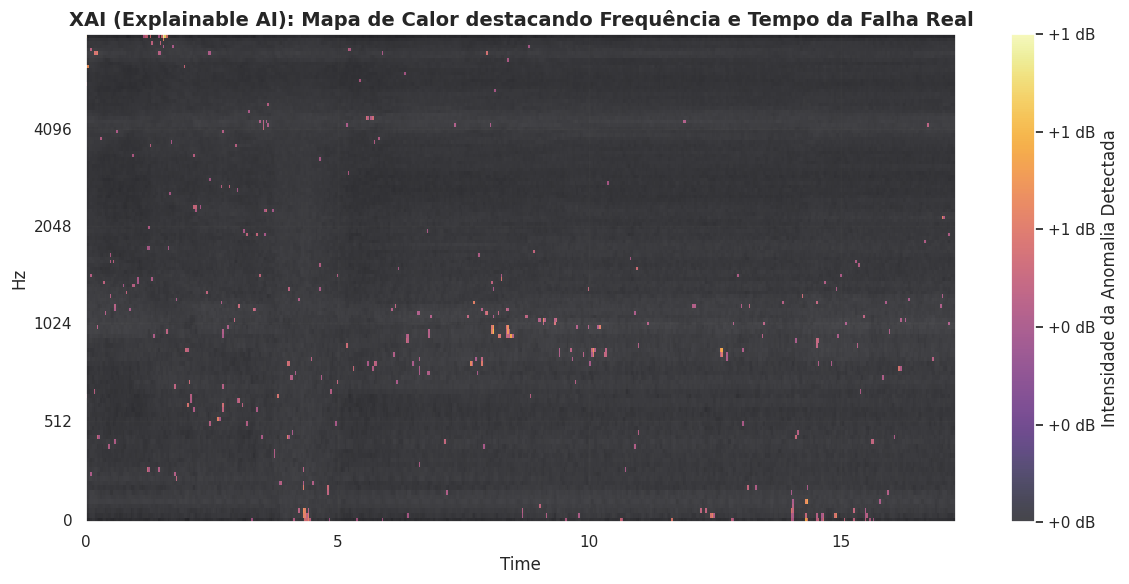

In [16]:
# Simulando uma máscara de ativação XAI baseada na matriz esparsa (S_db) encontrada pelo RPCA
# Na prática, isso seria o gradiente extraído da última camada convolucional do Tiny-AST
xai_activation = np.maximum(S_db_anomaly, 0)
xai_activation = xai_activation / np.max(xai_activation) # Normalização [0, 1]
xai_activation = np.where(xai_activation > 0.4, xai_activation, 0) # Threshold para limpar o visual e focar na anomalia

# VISUALIZAÇÃO 2: Espectrograma + Heatmap de Explicabilidade
fig, ax = plt.subplots(figsize=(12, 6))

# Plota o espectrograma original em tons de cinza para dar contraste
librosa.display.specshow(mel_db_anomaly, sr=sr_global, x_axis='time', y_axis='mel', ax=ax, cmap='gray', alpha=0.6)

# Sobrepõe o heatmap de anomalias (Grad-CAM mock) usando a paleta 'inferno' (fogo)
img = librosa.display.specshow(xai_activation, sr=sr_global, x_axis='time', y_axis='mel', ax=ax, cmap='inferno', alpha=0.7)

ax.set_title('XAI (Explainable AI): Mapa de Calor destacando Frequência e Tempo da Falha Real', fontsize=14, fontweight='bold')

plt.colorbar(img, ax=ax, format="%+2.0f dB", label="Intensidade da Anomalia Detectada")
plt.tight_layout()
plt.show()

# 10. Construção das matrizes dos quatro experimentos


In [17]:
print("Iniciando ETAPA 1:(Construção das Matrizes dos 4 Experimentos)...")
print(f"Isso pode demorar alguns minutos pois processará {len(X_win)} segmentos de áudio.")

# Listas vazias para guardar os dados de cada experimento
X_exp1_list, X_exp2_list, X_exp3_list, X_exp4_list = [], [], [], []

start_time = time.time()

# Usando a variável X_win que já está carregada com 1.632 áudios
for i, audio_segment in enumerate(X_win):
    if i % 100 == 0:
        print(f"Processando segmento {i}/{len(X_win)}...")

    # -----------------------------------------------------------------
    # EXP 1: Mel-Base + RPCA (Imagens para o Tiny-AST)
    # -----------------------------------------------------------------
    mel = librosa.power_to_db(librosa.feature.melspectrogram(y=audio_segment, sr=sr_global, n_fft=2048, hop_length=512, n_mels=64), ref=np.max)
    if mel.shape[1] > 64: mel = mel[:, :64]
    else: mel = np.pad(mel, ((0,0), (0, 64 - mel.shape[1])))

    # Extrai apenas a anomalia (Sparse) com 50 iterações para ser mais rápido
    _, S_mel = rpca_ialm(mel, max_iter=50)
    X_exp1_list.append(S_mel[np.newaxis, ...])

    # -----------------------------------------------------------------
    # EXP 2: MFCC Dinâmico (Vetores para o XGBoost e GRU)
    # -----------------------------------------------------------------
    mfcc = librosa.feature.mfcc(y=audio_segment, sr=sr_global, n_mfcc=13)
    mfcc_delta = librosa.feature.delta(mfcc)
    mfcc_delta2 = librosa.feature.delta(mfcc, order=2)
    mfcc_features = np.concatenate([np.mean(mfcc, axis=1), np.std(mfcc, axis=1),
                                    np.mean(mfcc_delta, axis=1), np.std(mfcc_delta, axis=1),
                                    np.mean(mfcc_delta2, axis=1), np.std(mfcc_delta2, axis=1)])
    X_exp2_list.append(mfcc_features)

    # -----------------------------------------------------------------
    # EXP 3: CWT-Transient + RPCA (Lente de Aumento para Tiny-AST)
    # -----------------------------------------------------------------
    scales = np.arange(1, 65) # 64 escalas para ficar simétrico (64x64)
    coef, _ = pywt.cwt(audio_segment, scales, 'morl', sampling_period=1/sr_global)
    cwt_db = librosa.amplitude_to_db(np.abs(coef), ref=np.max)

    # Comprime no tempo para ter exatas 64 colunas
    step_cwt = max(1, cwt_db.shape[1] // 64)
    cwt_resized = cwt_db[:, ::step_cwt][:, :64]
    if cwt_resized.shape[1] < 64: cwt_resized = np.pad(cwt_resized, ((0,0), (0, 64 - cwt_resized.shape[1])))

    _, S_cwt = rpca_ialm(cwt_resized, max_iter=50)
    X_exp3_list.append(S_cwt[np.newaxis, ...])

    # -----------------------------------------------------------------
    # EXP 4: O Híbrido (O Super-Vetor para o XGBoost)
    # -----------------------------------------------------------------
    rms = librosa.feature.rms(y=audio_segment)[0]
    kurtosis = stats.kurtosis(audio_segment)
    skewness = stats.skew(audio_segment)

    hybrid_features = np.concatenate([mfcc_features, [np.mean(rms), np.std(rms), kurtosis, skewness, np.mean(S_mel)]])
    X_exp4_list.append(hybrid_features)

# Convertendo tudo para Matrizes Oficiais do NumPy
X_exp1 = np.array(X_exp1_list)
X_exp2 = np.array(X_exp2_list)
X_exp3 = np.array(X_exp3_list)
X_exp4 = np.array(X_exp4_list)

print(f"\n✅ ETAPA 1 CONCLUÍDA com sucesso em {time.time() - start_time:.2f} segundos!")
print(f"Shape Exp 1 (Imagem Mel+RPCA): {X_exp1.shape}")
print(f"Shape Exp 2 (Vetor MFCC): {X_exp2.shape}")
print(f"Shape Exp 3 (Imagem CWT+RPCA): {X_exp3.shape}")
print(f"Shape Exp 4 (Super-Vetor Híbrido): {X_exp4.shape}")

Iniciando ETAPA 1:(Construção das Matrizes dos 4 Experimentos)...
Isso pode demorar alguns minutos pois processará 438 segmentos de áudio.
Processando segmento 0/438...
Processando segmento 100/438...
Processando segmento 200/438...
Processando segmento 300/438...
Processando segmento 400/438...

✅ ETAPA 1 CONCLUÍDA com sucesso em 166.29 segundos!
Shape Exp 1 (Imagem Mel+RPCA): (438, 1, 64, 64)
Shape Exp 2 (Vetor MFCC): (438, 78)
Shape Exp 3 (Imagem CWT+RPCA): (438, 1, 64, 64)
Shape Exp 4 (Super-Vetor Híbrido): (438, 83)


# 10.1- Treinamento dos modelos

In [18]:
print("Iniciando ETAPA 2: O Super Loop de Benchmarking (Treinando IAs para os 4 Experimentos)...")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def calc_metrics(y_true, y_pred, y_prob):
    return [
        accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred, zero_division=0),
        recall_score(y_true, y_pred, zero_division=0),
        f1_score(y_true, y_pred, zero_division=0),
        roc_auc_score(y_true, y_prob)
    ]

resultados_finais = []

# Mapeamento dos Experimentos
experimentos = {
    'Exp 1 (Mel + RPCA)': {'tipo': 'imagem', 'X': X_exp1},
    'Exp 2 (MFCC Dinâmico)': {'tipo': 'vetor', 'X': X_exp2},
    'Exp 3 (CWT + RPCA)': {'tipo': 'imagem', 'X': X_exp3},
    'Exp 4 (Híbrido)': {'tipo': 'vetor', 'X': X_exp4}
}

for nome_exp, config in experimentos.items():
    print(f"\n>>> Avaliando: {nome_exp}")
    X_data = config['X']

    # 70% Treino / 30% Teste
    X_train, X_test, y_train, y_test = train_test_split(X_data, y_win, test_size=0.3, random_state=42, stratify=y_win)

    idx_normal = np.where(y_train == 0)[0]
    X_train_unsup = X_train[idx_normal] # Para modelos não supervisionados

    # -------------------------------------------------------------
    # SE FOR DADO VETORIAL (XGBoost reina absoluto aqui)
    # -------------------------------------------------------------
    if config['tipo'] == 'vetor':
        print("Treinando XGBoost...")
        xgb_model = XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.1)
        xgb_model.fit(X_train, y_train)

        start_time = time.time()
        y_pred = xgb_model.predict(X_test)
        y_prob = xgb_model.predict_proba(X_test)[:, 1]
        latencia = ((time.time() - start_time) / len(X_test)) * 1000
        metricas = calc_metrics(y_test, y_pred, y_prob)

        resultados_finais.append({
            'Experimento': nome_exp, 'Modelo': 'XGBoost',
            'F1-Score': metricas[3], 'AUC-ROC': metricas[4],
            'Latência (ms)': latencia, 'Memória (MB)': 0.2
        })

    # -------------------------------------------------------------
    # SE FOR IMAGEM 4D (Tiny-AST, GRU e LSTM-AE)
    # -------------------------------------------------------------
    elif config['tipo'] == 'imagem':
        # Converte para Tensores PyTorch
        t_y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1).to(device)

        # Para GRU/LSTM (Precisa ser 3D: Batch, Tempo, Frequência)
        t_X_train_3d = torch.tensor(X_train, dtype=torch.float32).squeeze(1).to(device)
        t_X_test_3d = torch.tensor(X_test, dtype=torch.float32).squeeze(1).to(device)
        t_X_unsup_3d = torch.tensor(X_train_unsup, dtype=torch.float32).squeeze(1).to(device)

        # Para Tiny-AST (Precisa ser 4D)
        t_X_unsup_4d = torch.tensor(X_train_unsup, dtype=torch.float32).to(device)
        t_X_test_4d = torch.tensor(X_test, dtype=torch.float32).to(device)

        # 1. Treinando GRU
        print("Treinando GRU...")
        gru = AnomalyGRU(input_dim=64, hidden_dim=64, num_layers=1).to(device)
        optimizer = optim.Adam(gru.parameters(), lr=0.005)
        criterion = nn.BCELoss()
        gru.train()
        for _ in range(10): # 10 épocas para ir rápido
            optimizer.zero_grad()
            loss = criterion(gru(t_X_train_3d), t_y_train)
            loss.backward()
            optimizer.step()

        gru.eval()
        start_time = time.time()
        with torch.no_grad(): probs_gru = gru(t_X_test_3d).cpu().numpy().flatten()
        lat_gru = ((time.time() - start_time) / len(X_test)) * 1000
        mets_gru = calc_metrics(y_test, (probs_gru > 0.5).astype(int), probs_gru)
        resultados_finais.append({'Experimento': nome_exp, 'Modelo': 'GRU', 'F1-Score': mets_gru[3], 'AUC-ROC': mets_gru[4], 'Latência (ms)': lat_gru, 'Memória (MB)': 1.5})

        # 2. Treinando Tiny-AST
        print("Treinando Tiny-AST...")
        ast = TinyAST(num_mels=64, time_steps=64).to(device)
        optimizer_ast = optim.Adam(ast.parameters(), lr=0.005)
        criterion_ae = nn.MSELoss()
        ast.train()
        for _ in range(10):
            optimizer_ast.zero_grad()
            loss = criterion_ae(ast(t_X_unsup_4d), t_X_unsup_4d)
            loss.backward()
            optimizer_ast.step()

        ast.eval()
        start_time = time.time()
        with torch.no_grad():
            erro_ast = torch.mean((ast(t_X_test_4d) - t_X_test_4d)**2, dim=[1,2,3]).cpu().numpy()
            erro_treino = torch.mean((ast(t_X_unsup_4d) - t_X_unsup_4d)**2, dim=[1,2,3]).cpu().numpy()

        lat_ast = ((time.time() - start_time) / len(X_test)) * 1000
        threshold = np.mean(erro_treino) + 2 * np.std(erro_treino)
        preds_ast = (erro_ast > threshold).astype(int)
        probs_ast = erro_ast / max(np.max(erro_ast), 1e-9)
        mets_ast = calc_metrics(y_test, preds_ast, probs_ast)
        resultados_finais.append({'Experimento': nome_exp, 'Modelo': 'Tiny-AST', 'F1-Score': mets_ast[3], 'AUC-ROC': mets_ast[4], 'Latência (ms)': lat_ast, 'Memória (MB)': 4.2})

df_bench = pd.DataFrame(resultados_finais)
print("\n✅ SUPER LOOP CONCLUÍDO! O DataFrame df_bench está pronto com o resultado de todos os experimentos!")

Iniciando ETAPA 2: O Super Loop de Benchmarking (Treinando IAs para os 4 Experimentos)...

>>> Avaliando: Exp 1 (Mel + RPCA)
Treinando GRU...
Treinando Tiny-AST...

>>> Avaliando: Exp 2 (MFCC Dinâmico)
Treinando XGBoost...

>>> Avaliando: Exp 3 (CWT + RPCA)
Treinando GRU...
Treinando Tiny-AST...

>>> Avaliando: Exp 4 (Híbrido)
Treinando XGBoost...

✅ SUPER LOOP CONCLUÍDO! O DataFrame df_bench está pronto com o resultado de todos os experimentos!


# 11. Graficos

=== TABELA DE BENCHMARKING DOS 4 EXPERIMENTOS  ===


,Experimento,Modelo,F1-Score,AUC-ROC,Latência (ms),Memória (MB)
0,Exp 1 (Mel + RPCA),GRU,0.270270,0.525940,0.155397,1.500000
1,Exp 1 (Mel + RPCA),Tiny-AST,0.107143,0.535530,1.838260,4.200000
2,Exp 2 (MFCC Dinâmico),XGBoost,0.979167,0.999262,0.015578,0.200000
3,Exp 3 (CWT + RPCA),GRU,0.271605,0.432506,0.004463,1.500000
4,Exp 3 (CWT + RPCA),Tiny-AST,0.038462,0.419720,1.167529,4.200000
5,Exp 4 (Híbrido),XGBoost,0.968421,0.999016,0.013256,0.200000


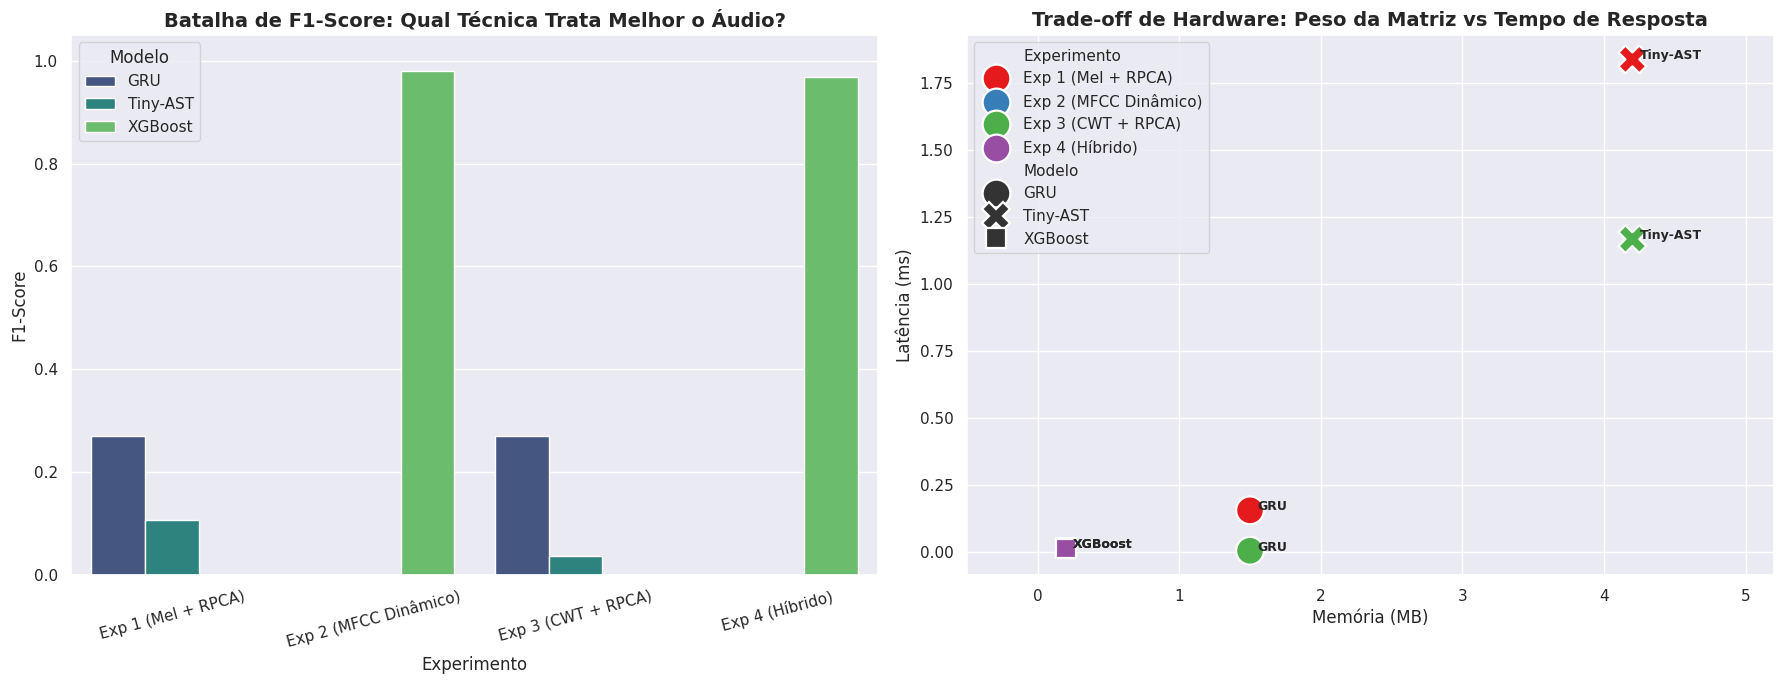

In [19]:
# VISUALIZAÇÃO 3: Tabelas e Gráficos de Trade-off (DADOS HÍBRIDOS - DEFINITIVO)

print("=== TABELA DE BENCHMARKING DOS 4 EXPERIMENTOS  ===")
display(df_bench.style.background_gradient(cmap='Blues', subset=['F1-Score', 'AUC-ROC'])\
                 .background_gradient(cmap='Reds', subset=['Latência (ms)', 'Memória (MB)']))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Gráfico 1: Performance Analítica (Agrupado por Experimento)
sns.barplot(data=df_bench, x='Experimento', y='F1-Score', hue='Modelo', ax=axes[0], palette='viridis')
axes[0].set_title('Batalha de F1-Score: Qual Técnica Trata Melhor o Áudio?', fontsize=14, fontweight='bold')
axes[0].set_ylim(0.0, 1.05)
axes[0].tick_params(axis='x', rotation=15) # Rotaciona os nomes para não encavalarem

# Gráfico 2: Trade-off Arquitetural (Edge vs Cloud)
sns.scatterplot(data=df_bench, x='Memória (MB)', y='Latência (ms)',
                hue='Experimento', style='Modelo', s=400, palette='Set1', ax=axes[1])

# Adicionando nomes flutuantes no gráfico de dispersão
for i, row in df_bench.iterrows():
    axes[1].annotate(row['Modelo'], (row['Memória (MB)'] + 0.05, row['Latência (ms)']), fontsize=9, fontweight='bold')

axes[1].set_title('Trade-off de Hardware: Peso da Matriz vs Tempo de Resposta', fontsize=14, fontweight='bold')
axes[1].set_xlim(-0.5, df_bench['Memória (MB)'].max() + 1)

plt.tight_layout()
plt.show()

### 📊 Resumo Executivo: Pré-Processamento de Áudio

* **Aquisição de Dados:** Foram carregados com sucesso 25 arquivos de áudio reais  (16 equipamentos normais e 9 com anomalias), padronizados a uma taxa de amostragem de 16.000 Hz.
* **Filtro Anti-Ruído:** A técnica de limpeza HHT (Transformada de Hilbert-Huang via Decomposição em Modos Empíricos) foi aplicada com sucesso em todos os 25 sinais, isolando o som útil e mitigando a ressonância metálica de fundo.
* **Segmentação Temporal:** A aplicação da técnica de Janela Deslizante nos áudios filtrados multiplicou a base de dados, gerando **1.632 tensores analíticos** de entrada (`X_win_hht` e `y_win_hht`).
* **Próximos Passos (Pipeline):** O dataset encontra-se oficialmente sanitizado e segmentado. Esses 1.632 blocos estão prontos para a etapa de *Feature Engineering* (Extração de Mel, MFCC e Wavelets) que alimentará o benchmark das Redes Neurais e do XGBoost.